In [1]:
# This is just for avoiding noise on the main code cell
import warnings
warnings.filterwarnings(action="ignore",category=UserWarning)

In [ ]:
### CREATING A SERIES OF POINTS ALONG A SINGLE DAY

# handling time the right way
from datetime import datetime
from zoneinfo import ZoneInfo

current_tz = ZoneInfo('America/Sao_Paulo')
start_time = datetime(2025, 9, 22, hour=7, tzinfo=current_tz)
end_time = datetime(2025, 9, 22, hour=17, tzinfo=current_tz)

# Converting to numpy (on UTC) and creating a day line
# Note that numpy converts to UTC automatically it warns that this behavior will stop working
# The way it is done here is to futureproof the code.
import numpy as np
utc = ZoneInfo('UTC')
np_start_time = np.datetime64(start_time.astimezone(utc), 'm')
np_time_delta = np.timedelta64(1,'h')                                # this sets the number of points (hour, minutes, second...)...
np_end_time  = np.datetime64(end_time.astimezone(utc), 'm') + np_time_delta
dayline = np.arange( np_start_time, np_end_time, np_time_delta)

# Setting the location to an specified point
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.units import deg
lat, lon = -15.783507525862756*deg, -47.91526919090653*deg # praça do cruzeiro, Brasília, DF
location = EarthLocation(lat=lat, lon=lon)

# Converting the points to astropy Time
from astropy.time import Time
ap_dayline = Time(dayline)

# Build a reference frame on Earth Surface
from astropy.coordinates import AltAz, get_sun
frame = AltAz(location=location, pressure=0)

# Calculating the sun position for all specified points
sun = get_sun(ap_dayline).transform_to(frame)

sun_alt = sun.alt.value
sun_az = sun.az.value


In [8]:
# Calculating the shadow of the plumb
plumb_length = 1.0
shadow_length = plumb_length / np.tan(np.deg2rad(sun_alt))
x = - shadow_length * np.sin(np.deg2rad(sun_az))
y = shadow_length * np.cos(np.deg2rad(sun_az))

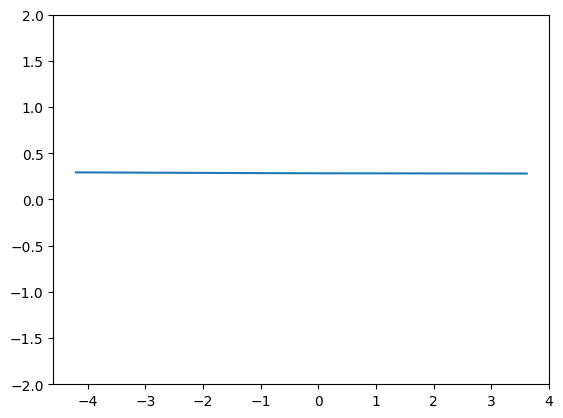

In [10]:
import matplotlib.pyplot as plt

plt.plot(x,y)
plt.ylim(-2,2)
plt.show()